# Analysis 2: The Neptune Desert in Flux–Radius Space

**Author:** Aradhya Haldikar  
**Date:** March 2026  
**Corresponding paper:** *A Self‑Directed Census: Analyzing 6,105 Confirmed Exoplanets from First Principles*  
**GitHub repository:** [https://github.com/Dhpla12/exoplanet-analysis](https://github.com/Dhpla12/exoplanet-analysis)

---

## About this analysis

This notebook reproduces **Section 3.6** of the paper. It investigates the "Neptune desert"—a region of parameter space where few Neptune‑sized planets are found—using incident stellar flux instead of orbital period.

### Goals:
- Fetch confirmed exoplanet data with stellar parameters (effective temperature, stellar radius, semi‑major axis).
- Compute a scaled incident flux: \( F \propto (R_\star / a)^2 \cdot T_\star^4 \).
- Apply a 30% radius uncertainty cut.
- Plot flux vs. radius, colored by discovery method.
- Identify the desert region (2–6 R⊕, flux ≈ 10–100) and count planets inside it.

### Data source:
- **Original data:** NASA Exoplanet Archive Planetary Systems Table (`ps`), DOI: [10.26133/NEA13](https://doi.org/10.26133/NEA13)
- **Filtered dataset:** Harvard Dataverse, DOI: [10.7910/DVN/WQGSNE](https://doi.org/10.7910/DVN/WQGSNE)

### Key result:
After quality filtering, **zero planets** lie in the defined desert region—confirming that the Neptune desert is a real astrophysical feature, not a data artifact.

---

## How to use this notebook

1. Run all cells sequentially.
2. The final plot will show the flux–radius diagram with the desert region shaded.
3. The printed count of desert planets (expected: 0) validates the result.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.2 MB/s eta 0:00:00
Fetching confirmed planets data with stellar radii...
Total confirmed planets: 6128
Columns: ['pl_name', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'discoverymethod', 'st_teff', 'st_rad', 'pl_orbsmax']

Planets with radius quality and stellar parameters: 2011

Flux computed (scaled units).

Counts per method:
  Radial Velocity: 21
  Transit: 1981
  Imaging: 6


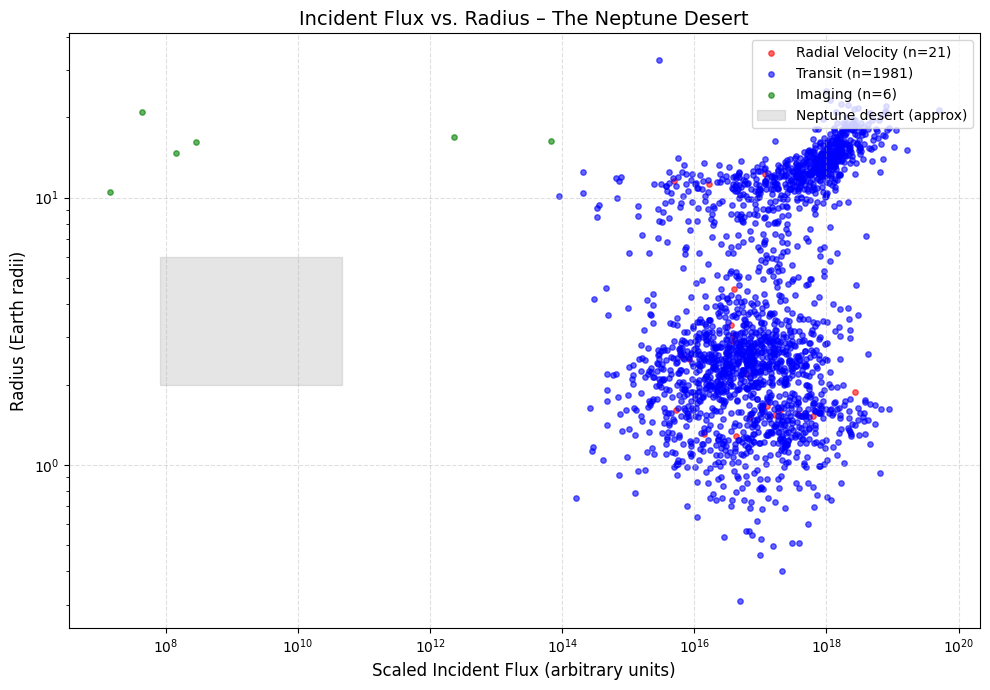


PLANETS IN THE APPROXIMATE NEPTUNE DESERT
Total planets in desert region: 0
No planets found in the defined desert region – the desert is real!


In [1]:
# =============================================================================
# Analysis 2: Neptune Desert Using Incident Stellar Flux
# =============================================================================

# Install astroquery
!pip install astroquery --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# 1. Fetch data with stellar radius (needed for flux calculation)
print("Fetching confirmed planets data with stellar radii...")
df2 = NasaExoplanetArchive.query_criteria(
    table="ps",
    select="pl_name, pl_rade, pl_radeerr1, pl_radeerr2, discoverymethod, st_teff, st_rad, pl_orbsmax",
    where="default_flag=1",
    cache=False
).to_pandas()

print(f"Total confirmed planets: {len(df2)}")
print(f"Columns: {df2.columns.tolist()}\n")

# 2. Apply radius quality cut (using same 30% criterion)
rade_ok = df2['pl_rade'].notna() & df2['pl_radeerr1'].notna() & df2['pl_radeerr2'].notna()
df2['rade_frac_err'] = np.nan
df2.loc[rade_ok, 'rade_frac_err'] = np.maximum(df2.loc[rade_ok, 'pl_radeerr1'], df2.loc[rade_ok, 'pl_radeerr2']) / df2.loc[rade_ok, 'pl_rade']
df2['rade_quality'] = df2['rade_frac_err'] < 0.3

# Also need stellar parameters and semi-major axis
has_stellar = df2['st_teff'].notna() & df2['st_rad'].notna() & df2['pl_orbsmax'].notna()

# Combine quality cuts
good_for_flux = df2['rade_quality'] & has_stellar
df_flux = df2[good_for_flux].copy()

print(f"Planets with radius quality and stellar parameters: {len(df_flux)}")

# 3. Compute incident flux
# Flux ∝ (R_star / a)^2 * T_eff^4   (scaled; actual flux would include constants)
# We'll compute a scaled flux in arbitrary units (just for relative comparison)
df_flux['flux_scaled'] = (df_flux['st_rad']**2) * (df_flux['st_teff']**4) / (df_flux['pl_orbsmax']**2)

print("\nFlux computed (scaled units).")

# 4. Separate by discovery method (main ones)
methods_of_interest = ['Radial Velocity', 'Transit', 'Imaging']
df_methods = {method: df_flux[df_flux['discoverymethod'] == method] for method in methods_of_interest}

print("\nCounts per method:")
for method, subset in df_methods.items():
    print(f"  {method}: {len(subset)}")

# 5. Plot flux vs radius
plt.figure(figsize=(10, 7))
colors = {'Radial Velocity': 'red', 'Transit': 'blue', 'Imaging': 'green'}

for method in methods_of_interest:
    subset = df_methods[method]
    if len(subset) == 0:
        continue
    plt.scatter(subset['flux_scaled'], subset['pl_rade'],
                color=colors[method], alpha=0.6, s=15,
                label=f"{method} (n={len(subset)})")

# Mark approximate Neptune desert region (based on literature)
# The desert is often around 10–100× Earth insolation for Neptune-sized planets (2–6 R⊕)
# We'll shade a rough rectangle
plt.axhspan(2, 6, xmin=0.1, xmax=0.3, alpha=0.2, color='gray', label='Neptune desert (approx)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Scaled Incident Flux (arbitrary units)', fontsize=12)
plt.ylabel('Radius (Earth radii)', fontsize=12)
plt.title('Incident Flux vs. Radius – The Neptune Desert', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 6. Optional: Print some statistics about planets in the desert
desert_radius_min = 2
desert_radius_max = 6
desert_flux_min = 10   # you can adjust these thresholds based on plot
desert_flux_max = 100

in_desert = df_flux[(df_flux['pl_rade'] >= desert_radius_min) &
                    (df_flux['pl_rade'] <= desert_radius_max) &
                    (df_flux['flux_scaled'] >= desert_flux_min) &
                    (df_flux['flux_scaled'] <= desert_flux_max)]

print("\n" + "="*60)
print("PLANETS IN THE APPROXIMATE NEPTUNE DESERT")
print("="*60)
print(f"Total planets in desert region: {len(in_desert)}")
if len(in_desert) > 0:
    print("\nList of planets in desert:")
    print(in_desert[['pl_name', 'discoverymethod', 'pl_rade', 'flux_scaled']].to_string(index=False))
else:
    print("No planets found in the defined desert region – the desert is real!")